In [1]:
import baseline_electricity_model
import pandas as pd

In [2]:
from baseline_electricity_model import run_pipeline, run_pipeline_v2

In [3]:
CONSO_PATH = "base_data/FR_gas/conso_gas_reg_daily.csv"
TEMP_PATH = "base_data/temp_era/temp_FR_daily_era.csv"

In [22]:
models, baselines, calendar_df = run_pipeline_v2(CONSO_PATH, TEMP_PATH, alpha = 0.7, vector = "gas", month_effect=True)

[load_data] Période retenue : 2018-06-01 → 2025-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2040

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.7)
  Température CDD  : T_obs
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc2     N
---

In [30]:
models_nom, baselines_nom, calendar_df = run_pipeline_v2(CONSO_PATH, TEMP_PATH, alpha=0.4, vector = "gas", month_effect=False)

[load_data] Période retenue : 2018-06-01 → 2025-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2040

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.4)
  Température CDD  : T_obs
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc2     N
---

In [7]:
temp = pd.read_csv(TEMP_PATH, index_col = 0, parse_dates = True)
conso = pd.read_csv(CONSO_PATH, index_col = 0, parse_dates = True)
models["Île-de-France"]

{'results': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1a60ed12ad0>,
 'T_c1': 15.850000000000112,
 'T_c2': None,
 'alpha_eff': 0.7,
 'alpha_cdd': 1,
 'calendar_v': 2}

<Axes: title={'center': 'Bretagne 2022 — décomposition'}, xlabel='Date'>

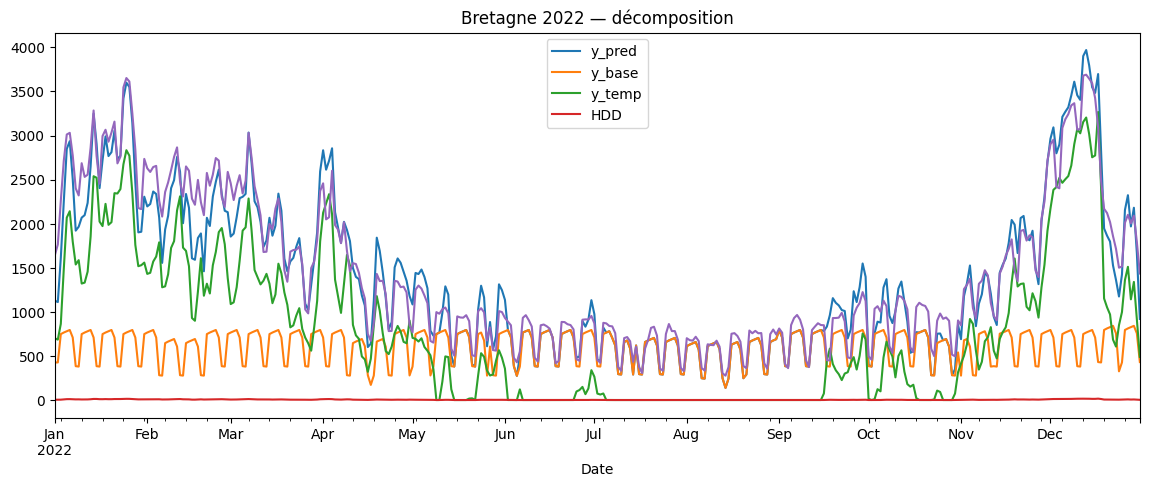

In [8]:
from baseline_electricity_model import predict_demand, get_school_holidays

_, region_zone_map = get_school_holidays(list(range(2010, 2025)))

# Reconstruire la demande pour l'Île-de-France sur 2022
df = predict_demand(
    models["Bretagne"],
    "Bretagne",
    region_zone_map,
    temp["Bretagne"].loc["2022"]
)

# df contient :
# y_pred : demande totale (calendaire + T°)
# y_base : demande structurelle pure (sans effet T°)
# y_temp : part de la demande due à la température

df.plot(figsize=(14, 5), title="Bretagne 2022 — décomposition")
conso["Bretagne"].loc["2022"].plot(label = "y_true")


### Diagnostic

In [10]:
from baseline_electricity_model import summarize_model_stats, get_school_holidays
import matplotlib.pyplot as plt

# 1. Résumé global R², seuils
print(summarize_model_stats(models)[["R2", "R2_adj", "RMSE", "T_c1_°C"]])


                                R2  R2_adj     RMSE  T_c1_°C
region                                                      
Auvergne-Rhône-Alpes        0.9436  0.9432   584.25    14.10
Bourgogne-Franche-Comté     0.9236  0.9231   299.80    16.25
Bretagne                    0.9000  0.8994   276.22    15.85
Centre-Val de Loire         0.9259  0.9255   231.30    16.65
Grand Est                   0.9337  0.9333   605.56    16.05
Hauts-de-France             0.9201  0.9196   679.23    15.75
Normandie                   0.9140  0.9135   291.93    15.80
Nouvelle-Aquitaine          0.9272  0.9268   409.61    16.90
Occitanie                   0.9274  0.9270   312.41    15.55
Pays de la Loire            0.9207  0.9202   319.90    16.30
Provence-Alpes-Côte d'Azur  0.9317  0.9313   260.82    14.15
Île-de-France               0.9359  0.9355  1137.89    16.30


In [11]:
# 2. Tous les coefficients d'une région avec significativité
def print_coefficients(models, region):
    m        = models[region]
    results  = m["results"]
    params   = results.params
    pvalues  = results.pvalues
    conf     = results.conf_int()

    print(f"\n{'='*65}")
    print(f"  {region}  |  T_c1 = {m['T_c1']:.2f}°C  |  R² = {results.rsquared:.4f}")
    print(f"{'='*65}")
    print(f"  {'Variable':<25} {'Coeff':>12} {'IC 95% bas':>12} {'IC 95% haut':>12}  {'p':>7}")
    print(f"  {'-'*63}")
    for var in params.index:
        sig = "***" if pvalues[var] < 0.001 else "**" if pvalues[var] < 0.01 else "*" if pvalues[var] < 0.05 else ""
        print(f"  {var:<25} {params[var]:>12.1f} {conf.loc[var,0]:>12.1f} {conf.loc[var,1]:>12.1f}  "
              f"{pvalues[var]:>6.4f} {sig}")

print_coefficients(models, "Île-de-France")



  Île-de-France  |  T_c1 = 16.30°C  |  R² = 0.9359
  Variable                         Coeff   IC 95% bas  IC 95% haut        p
  ---------------------------------------------------------------
  const                           1860.0       1554.3       2165.8  0.0000 ***
  HDD                              868.2        849.2        887.2  0.0000 ***
  dow_0                            345.9        224.5        467.4  0.0000 ***
  dow_1                            281.3        138.1        424.5  0.0001 ***
  dow_2                            356.3        202.7        509.9  0.0000 ***
  dow_3                            407.6        248.4        566.7  0.0000 ***
  dow_4                            286.2        142.4        430.0  0.0001 ***
  dow_5                            -45.2       -163.4         73.1  0.4541 
  is_holiday                      -165.7       -429.2         97.8  0.2177 
  is_eve                           -87.0       -344.3        170.2  0.5073 
  is_bridge              

In [13]:
# 3. Décomposition des contributions par groupe de variables
def decompose_contributions(models, region, temp_region, calendar_df, region_zone_map):
    """Décompose la prédiction en groupes : T°, mois, jour, calendaire, rupture, constante."""
    from baseline_electricity_model import build_feature_matrix_v2
    m       = models[region]
    results = m["results"]
    T_c1    = m["T_c1"]

    X = build_feature_matrix_v2(temp_region, calendar_df, region, region_zone_map, T_c1, None, vector = "gas")
    X = X.reindex(columns=results.model.exog_names, fill_value=0.0)
    beta = results.params

    groups = {
        "constante":  ["const"],
        "température (HDD)": [c for c in X.columns if c == "HDD"],
        "mois":       [c for c in X.columns if c.startswith("month_")],
        "jour semaine": [c for c in X.columns if c.startswith("dow_")],
        "calendaire": ["is_holiday", "is_eve", "is_bridge", "is_vacances"],
        "post_rupture": ["post_rupture"],
    }

    contribs = {}
    for name, cols in groups.items():
        cols_ok = [c for c in cols if c in X.columns]
        if cols_ok:
            contribs[name] = (X[cols_ok] * beta[cols_ok]).sum(axis=1)

    df_out = pd.DataFrame(contribs, index=X.index)
    df_out["total_predit"] = df_out.sum(axis=1)
    return df_out

_, region_zone_map = get_school_holidays(list(range(2010, 2025)))

dc = decompose_contributions(models, "Île-de-France", temp["Île-de-France"], calendar_df, region_zone_map)
dc.plot(figsize=(16, 5), title="Contributions par groupe — Île-de-France (gaz)")
plt.axhline(0, color="black", lw=0.8, ls="--")
plt.ylabel("GWh/j")
plt.show()


KeyError: "['is_sat_or_bridge', 'is_early_august', 'vac_noel_zone_C', 'vac_ete_zone_C', 'vac_other_zone_C'] not in index"

In [43]:
# 4. Zoom : valeur de post_rupture par région
print("\nCoefficient post_rupture par région :")
for reg, m in models.items():
    coef = m["results"].params.get("post_rupture", float("nan"))
    mean_conso = conso[reg].mean()
    print(f"  {reg:<35} post_rupture = {coef:>10.1f}   "
          f"({100*coef/mean_conso:>+.1f}% de la conso moyenne)")



Coefficient post_rupture par région :
  Auvergne-Rhône-Alpes                post_rupture =     -628.0   (-18.0% de la conso moyenne)
  Bourgogne-Franche-Comté             post_rupture =     -338.0   (-22.0% de la conso moyenne)
  Bretagne                            post_rupture =     -206.4   (-13.6% de la conso moyenne)
  Centre-Val de Loire                 post_rupture =     -271.5   (-22.6% de la conso moyenne)
  Grand Est                           post_rupture =     -764.6   (-22.2% de la conso moyenne)
  Hauts-de-France                     post_rupture =     -658.0   (-18.5% de la conso moyenne)
  Normandie                           post_rupture =     -364.5   (-21.8% de la conso moyenne)
  Nouvelle-Aquitaine                  post_rupture =     -429.2   (-20.6% de la conso moyenne)
  Occitanie                           post_rupture =     -297.2   (-19.5% de la conso moyenne)
  Pays de la Loire                    post_rupture =     -269.2   (-15.9% de la conso moyenne)
  Provence-

Now, we want to extract the baseline, and build it for a given year

Figure sauvegardée : pred_vs_reel_gaz.png


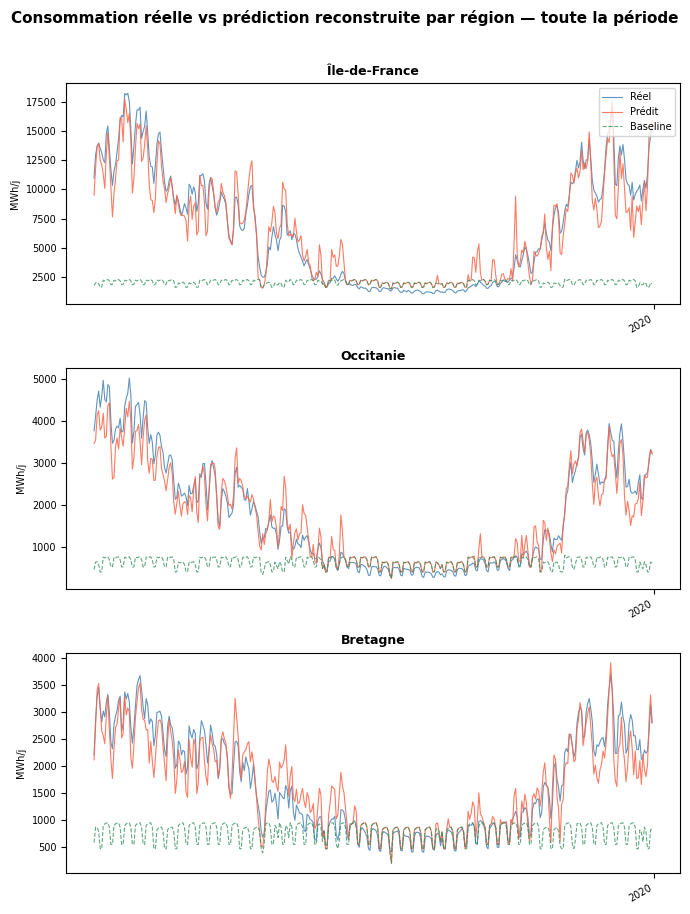

In [14]:
from baseline_electricity_model import (
    plot_predictions_vs_actual, get_school_holidays, predict_demand
)

# Après avoir fitté les modèles :
_, region_zone_map = get_school_holidays(list(range(2010, 2025)))

# Électricité
# plot_predictions_vs_actual(models, conso, temp, region_zone_map,
#                            ncols=3, save="pred_vs_reel_elec.png")

# Gaz (même appel, models_gas)
plot_predictions_vs_actual(models, conso, temp.loc["2019"], region_zone_map,
                           ncols=1, save="pred_vs_reel_gaz.png", regs = ["Île-de-France", "Occitanie", "Bretagne"])


In [46]:
predict_demand(models["Île-de-France"], "Île-de-France",
                                   region_zone_map, temp["Île-de-France"].loc["2022"])

,y_pred,y_base,y_temp
Date,,,
2022-01-01,8763.568975,5204.576364,3558.992611
2022-01-02,7411.105724,5204.576364,2206.529360
2022-01-03,8016.532219,5598.692903,2417.839315
2022-01-04,10096.880038,5595.952566,4500.927472
2022-01-05,13754.107914,5602.759517,8151.348397
...,...,...,...
2022-12-27,11572.574768,5032.341005,6540.233763
2022-12-28,8306.755769,5039.147955,3267.607814
2022-12-29,8637.920975,5082.464165,3555.456809


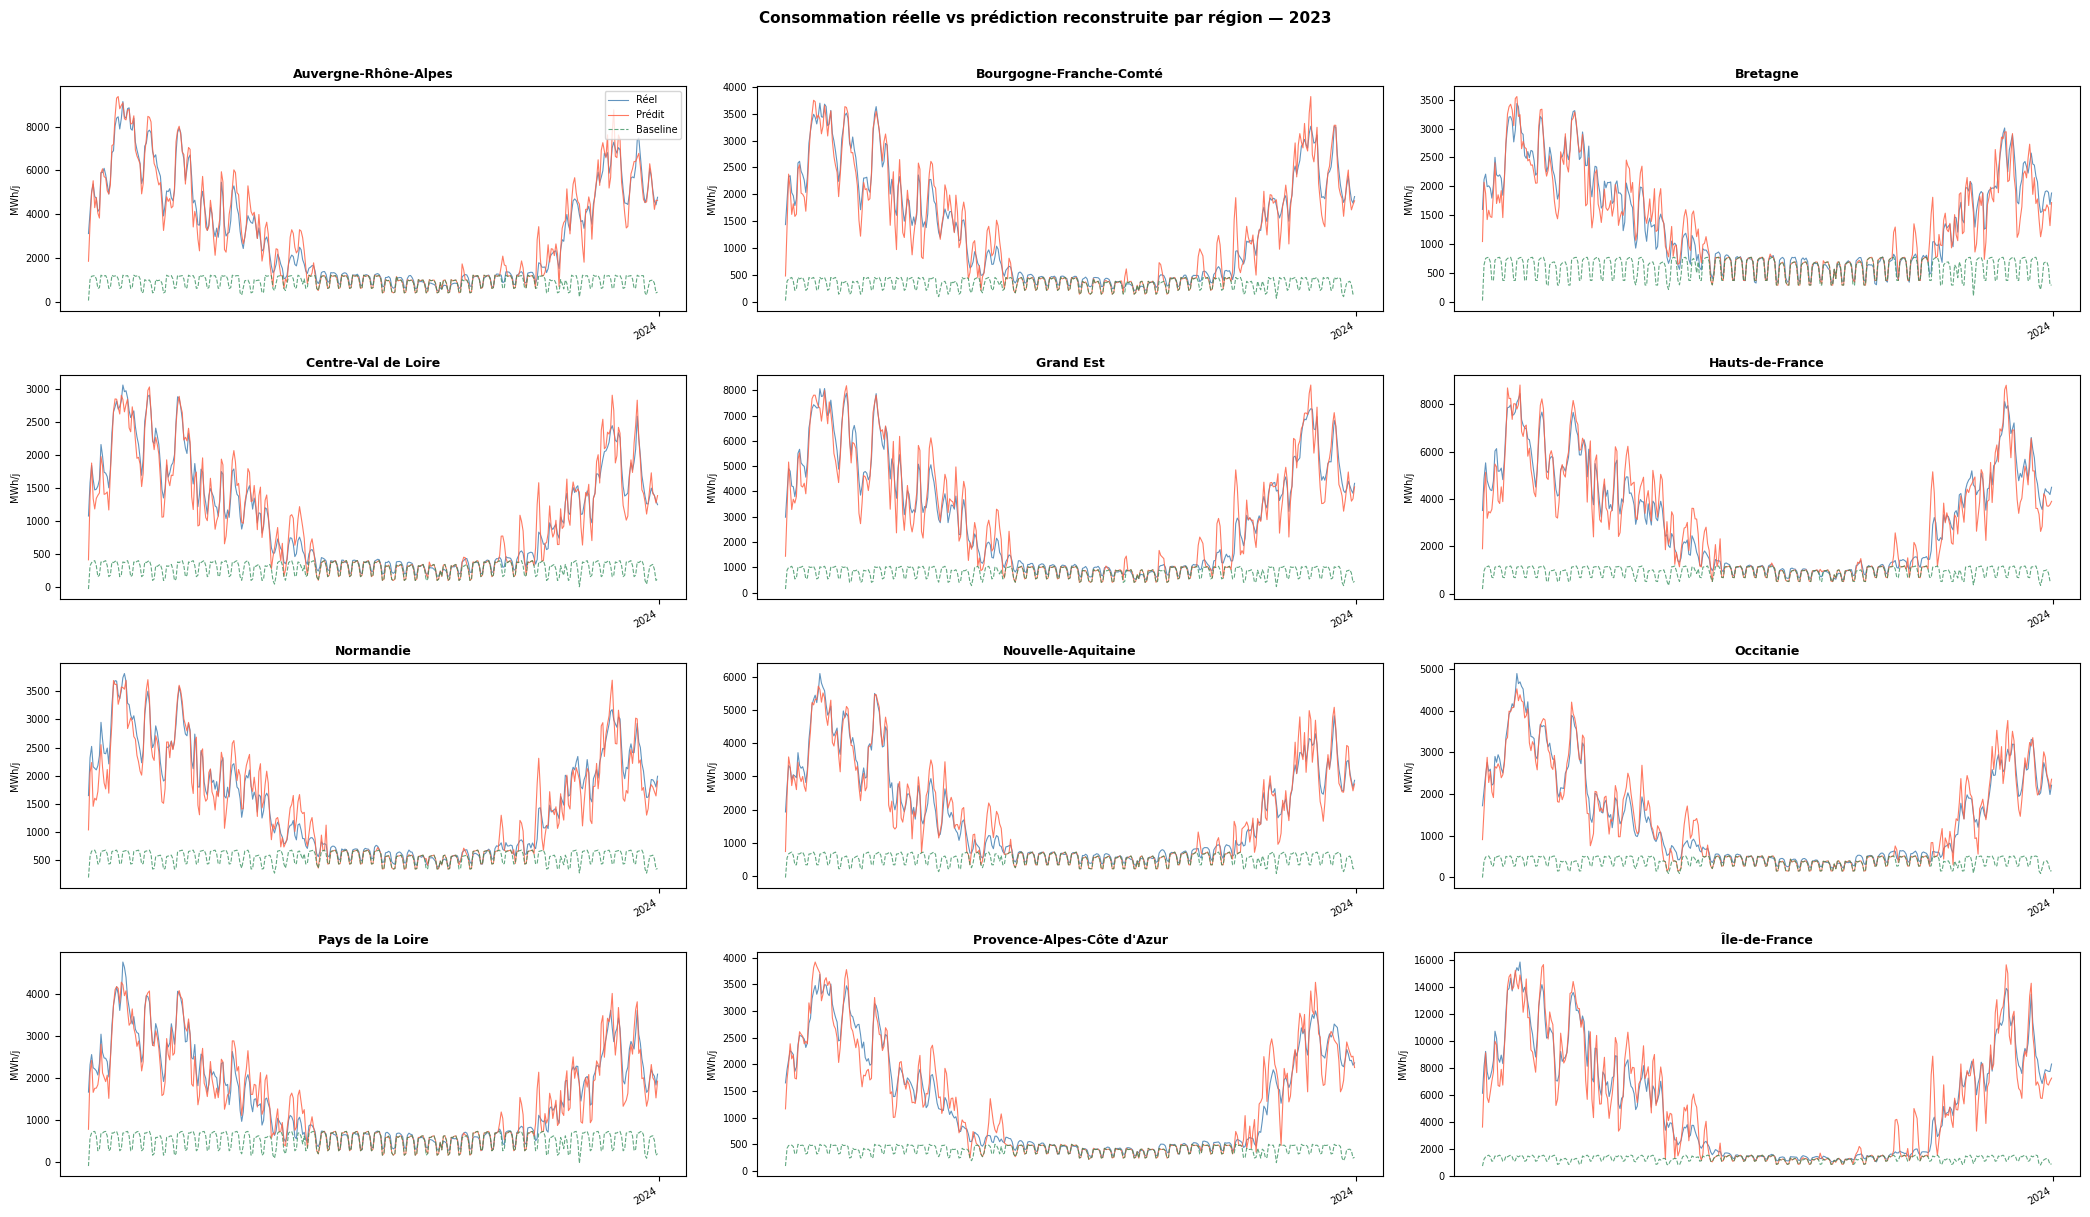

: 

In [ ]:
plot_predictions_vs_actual(models, conso, temp, region_zone_map, year = 2023)

Modèle de base avec effet-mois

In [23]:
heating_rate = 0 
for r in temp.columns:
    heating_rate += models[r]["results"].params["HDD"]

print(f"National rate gas:       heating --> {heating_rate:.1f} MW/°C")

National rate gas:       heating --> 3215.7 MW/°C


Modèle sans effet mois

In [31]:
heating_rate = 0 
for r in temp.columns:
    heating_rate += models_nom[r]["results"].params["HDD"]

print(f"National rate gas:       heating --> {heating_rate:.1f} MW/°C")

National rate gas:       heating --> 4388.6 MW/°C


In [32]:
df_thresh_n_rates = pd.DataFrame(index = temp.columns)
df_thresh_n_rates["heating_rate"] = 0
df_thresh_n_rates["heating_threshold"] = 0
for r in df_thresh_n_rates.index:
    df_thresh_n_rates["heating_rate"].loc[r] = models_nom[r]["results"].params["HDD"]
    df_thresh_n_rates["heating_threshold"].loc[r] = models_nom[r]["T_c1"]

df_thresh_n_rates.to_csv("gas_thermo_parameters_no_month.csv")

In [49]:
from sklearn.metrics import root_mean_squared_error as rmse

In [50]:
rmse(dc["total_predit"].loc["2022"], conso["Île-de-France"].loc["2022"])/conso["Île-de-France"].loc["2022"].mean()

0.1383683320471155

Baseline decomposition

In [33]:
baseline_noT_gas = pd.DataFrame()

In [34]:
for r in temp.columns:
    baseline = predict_demand(models_nom[r], r,
                                   region_zone_map, temp[r])["y_base"]
    baseline_noT_gas[r]=baseline

In [35]:
baseline_noT_gas.to_csv("final_predictions/daily_baselines/baseline_no_month_gas_regions.csv")

In [53]:
baseline_noT_gas.sum(axis=1).to_csv("final_predictions/baseline_noT_gas.csv")

#### Coefficient thermosensible pour le gaz

In [19]:
def calcul_demande_moyenne_thermosensible(models, reg, region_zone_map, temp):
    nb_years = len(temp.index.year.unique().to_list())


    HDD_tot = predict_demand(models[reg], reg, region_zone_map, temp[reg], True)["HDD"].sum()

    heat_rate = models[reg]["results"].params["HDD"]

    heat_demand = heat_rate*HDD_tot/1e6*24/nb_years

    #print(f"Demande thermosensible moyenne en {reg}:")
    #print(f"heating: {heat_demand:.2f} TWh/an, cooling: {cool_demand:.2f} TWh/an")

    return heat_demand

In [36]:
tot_heat = 0
for r in temp.columns:
    #print(r)
    heat = calcul_demande_moyenne_thermosensible(models, r, region_zone_map, temp)
    tot_heat += heat
print(f"Demande thermosensible moyenne en France:")
print(f"heating: {tot_heat:.2f} TWh/an")

Demande thermosensible moyenne en France:
heating: 110.15 TWh/an


In [37]:
tot_heat = 0
for r in temp.columns:
    #print(r)
    heat = calcul_demande_moyenne_thermosensible(models_nom, r, region_zone_map, temp)
    tot_heat += heat
print(f"Demande thermosensible moyenne en France:")
print(f"heating: {tot_heat:.2f} TWh/an")

Demande thermosensible moyenne en France:
heating: 176.05 TWh/an
